In [14]:
import torch as torch
import matplotlib.pyplot as plt
import numpy as np

In [94]:
from src.loss_functions import f_activation, f_lower_bound

tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(20.)
tensor(20.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)


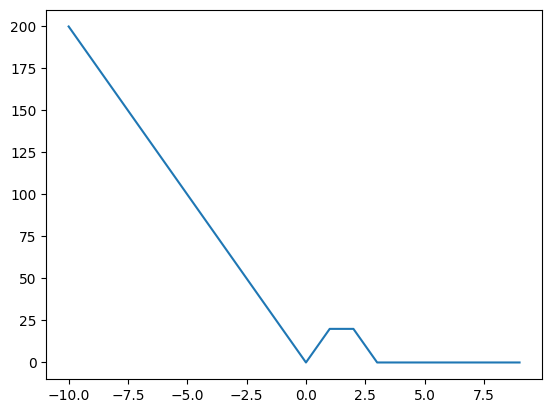

In [95]:
y = []
for i in range(-10,10):
    val = torch.zeros(1)
    val[0] = i

    y.append(f_activation(val[0],3)+f_lower_bound(val[0],0))


plt.plot(range(-10,10),y)

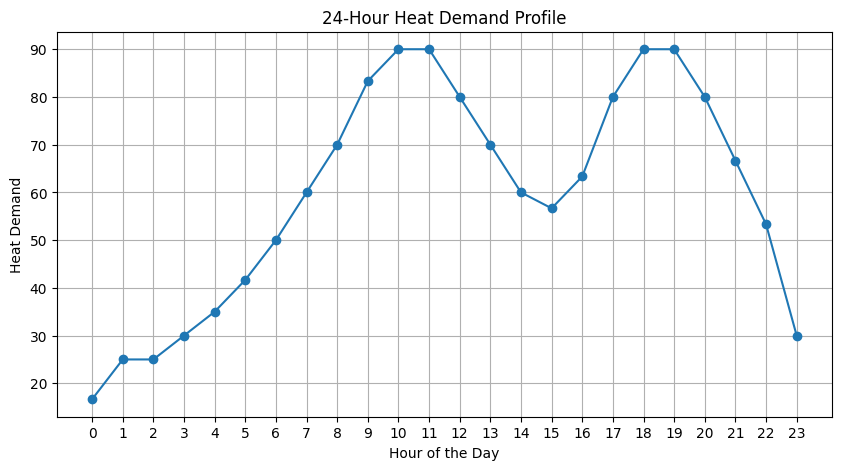

In [24]:

# Time array for 24 hours with 1-hour time steps
time = np.arange(0, 24, 1)

# Define the window size for the moving average
window_size = 3

# Initial heat demand profile (baseline)
heat_demand = [30, 20, 25, 30, 35, 40, 50, 60, 70, 80, 100, 90, 80, 70, 60, 50, 60, 80, 100, 90, 80, 70, 50, 40]
# Compute the moving average
smoothed_heat_demand = np.convolve(heat_demand, np.ones(window_size)/window_size, mode='same')

# Convert the result back to a list
smoothed_heat_demand = smoothed_heat_demand

# Plot the heat demand profile
plt.figure(figsize=(10, 5))
plt.plot(time, smoothed_heat_demand, marker='o')
plt.title('24-Hour Heat Demand Profile')
plt.xlabel('Hour of the Day')
plt.ylabel('Heat Demand')
plt.grid(True)
plt.xticks(time)
plt.show()


In [41]:
d = torch.zeros(50,24,1)  


In [58]:
for i in range(50):
    d[i] = torch.from_numpy(smoothed_heat_demand).reshape(24,1)

d.size()
data = d + torch.randn(50,24,1)
data_x0 = 40 + 40*torch.rand(50, 1) 



for i in range(50): 
    data[i][0] = data_x0[i]


data.size()


torch.Size([50, 24, 1])

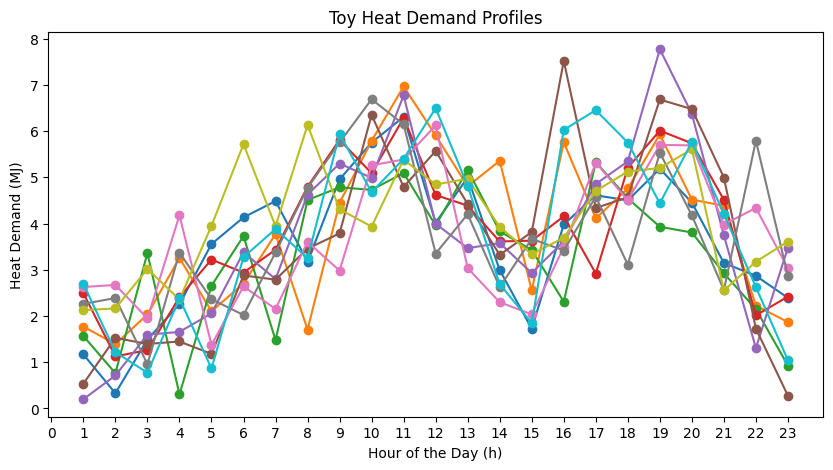

In [69]:

# Time array for 24 hours with 1-hour time steps
time = np.arange(0, 24, 1)

# Define the window size for the moving average
window_size = 3

# Initial heat demand profile (baseline)
heat_demand = [30, 20, 25, 30, 35, 40, 50, 60, 70, 80, 100, 90, 80, 70, 60, 50, 60, 80, 100, 90, 80, 70, 50, 40]
# Compute the moving average
smoothed_heat_demand = np.convolve(heat_demand, np.ones(window_size)/window_size, mode='same')

# Convert the result back to a list
smoothed_heat_demand = smoothed_heat_demand*0.06


for i in range(50):
    d[i] = torch.from_numpy(smoothed_heat_demand).reshape(24,1)

d.size()
data = torch.abs(d + torch.randn(50,24,1))
data_x0 = 40 + 40*torch.rand(50, 1) 



for i in range(50): 
    data[i][0] = data_x0[i]


# Plot the heat demand profile
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.plot(time[1:], data[i][1:], marker='o')
plt.title('Toy Heat Demand Profiles')
plt.xlabel('Hour of the Day (h)')
plt.ylabel('Heat Demand (MJ)')
plt.xticks(time) 
plt.show()

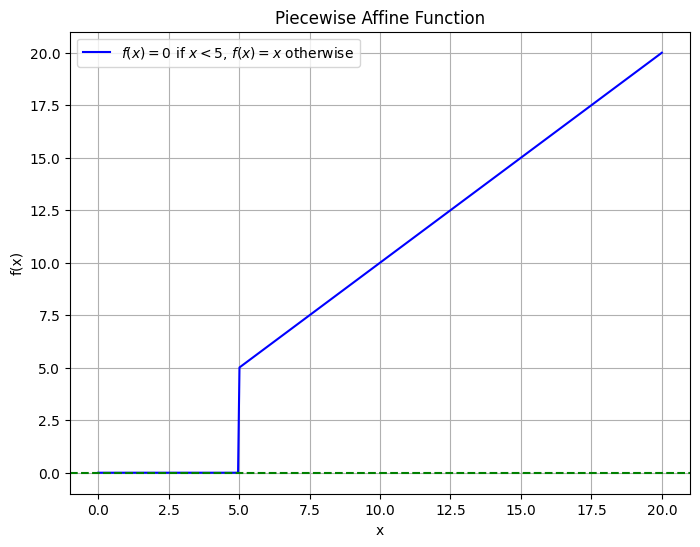

In [73]:

# Define the piecewise function
def f(x):
    return np.where(x < 5, 0, x)

# Define the interval
x = np.linspace(0, 20, 400)

# Compute the function values
y = f(x)

# Plot the function
plt.figure(figsize=(8, 6))
plt.plot(x, y, label='$f(x) = 0$ if $x<5$, $f(x) = x$ otherwise', color='b')
plt.axhline(0, color='g', linestyle='--')

# Adding titles and labels
plt.title('Piecewise Affine Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


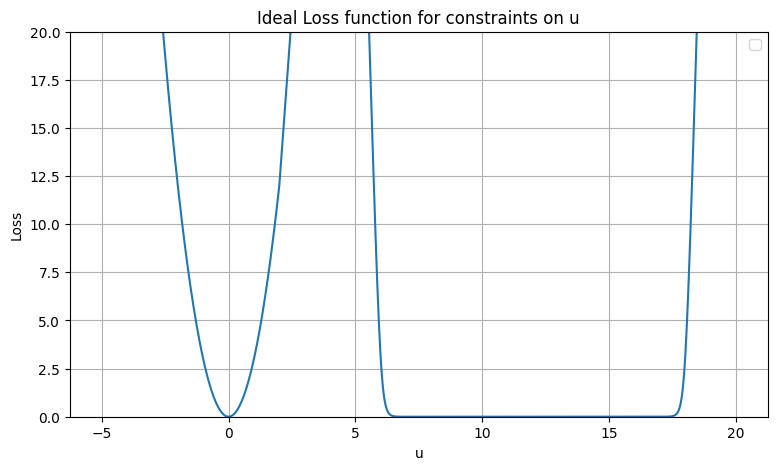

In [86]:

# Define the piecewise function
def f(x):
    if x < 5:
        return 3*x**2
    else:
        return 10*(np.log10(1 + np.exp(10*(6 - x))) + np.log10(1 + np.exp(10*(x - 18))))

# Generate x values
x_values = np.concatenate((np.linspace(-5, 2, 500), np.linspace(4, 20, 500)))
# Generate y values using the piecewise function
y_values = np.array([f(x) for x in x_values])

# Plot the function
plt.figure(figsize=(9, 5))
plt.plot(x_values, y_values)
plt.title("Ideal Loss function for constraints on u")
plt.xlabel("u")
plt.ylabel("Loss")
plt.ylim(0,20)
plt.legend()
plt.grid(True)
plt.show()
